# Loading the Libraries for the Prediction Model 

In [20]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, mean_absolute_error, accuracy_score
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from itertools import combinations
from collections import Counter

# Web Scraping

In [ ]:
URL = "https://www.transfermarkt.com/weltmeisterschaft/teilnehmer/pokalwettbewerb/FIWC/saison_id/2025"

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0 Safari/537.36"
    )
}

response = requests.get(URL, headers=HEADERS)
response.raise_for_status()

soup = BeautifulSoup(response.content, "html.parser")

teams = []

for table in soup.select("table.items"):
    header_cells = [th.get_text(strip=True) for th in table.select("thead th")]
    header_cells = [h for h in header_cells if h]

    for tr in table.select("tbody tr"):
        cells = tr.find_all("td")
        if not cells:
            continue

        club_link = tr.find("a", href=lambda h: h and "/startseite/verein/" in h)
        if not club_link:
            continue

        texts = [td.get_text(strip=True) for td in cells if td.get_text(strip=True)]

        row = {
            "Club": club_link.get_text(strip=True),
        }

        n = min(len(header_cells), len(texts))
        for h, v in zip(header_cells[-n:], texts[-n:]):
            row[h] = v

        teams.append(row)

df = pd.DataFrame(teams)
print(df)
df.to_csv("world_cup_2026_participants.csv", index=False)

# Loading the Data and Cleaning

In [2]:
Elo = pd.read_csv("C:\\Project DATA\\2026 Fifa WC Winner\\Data\\elo_ratings_wc2026.csv")
WC_2026_Squads = pd.read_csv("Data\\world_cup_2026_participants.csv",  encoding='latin-1')
Results = pd.read_csv("C:\\Project DATA\\2026 Fifa WC Winner\\Data\\results.csv")
Shootouts = pd.read_csv("C:\\Project DATA\\2026 Fifa WC Winner\\Data\\shootouts.csv")
Schedule = pd.read_csv("C:\\Project DATA\\2026 Fifa WC Winner\\Data\\world-cup-2026-schedule.csv")

In [3]:
team_dictionary = {
    'Czech Republic': 'Czechia',                              
    'Bosnia-Herzegovina': 'Bosnia and Herzegovina',            
    'Democratic Republic of the Congo': 'DR Congo',            
    'Turkiye': 'Turkey',                                       
    'Cabo Verde': 'Cape Verde',                                
    'Congo DR': 'DR Congo',                                   
    'Côte d’Ivoire': 'Ivory Coast',                            
    'Korea Republic': 'South Korea',                           
    'Türkiye': 'Turkey',    
    'United States': 'USA',   
    'Congo DR' : 'DR Congo',
    "Curaçao": "Curacao", 
    "CuraÃ§ao": "Curacao",                           
}

In [4]:
# Grabbing the first 48 rows of the squads data to ensure we have only the participating teams.
WC_2026_Squads_Cleaned = WC_2026_Squads.iloc[0:48].copy()

WC_2026_Squads_Cleaned['Club'] = WC_2026_Squads_Cleaned['Club'].str.strip().replace(team_dictionary)

WC_2026_Squads_Cleaned = WC_2026_Squads_Cleaned.rename(columns={
    'Club': 'team',
    '&oslash-Age': 'Average Age',
    '&oslash-Market Value': 'Average Market Value(In Euros)',
    'Market Value': 'Market Value(In Euros)',
    'WC particip.': 'WC Participations',
})

WC_2026_Squads_Cleaned['Foreigners'] = (
    WC_2026_Squads_Cleaned['Foreigners'].str.rstrip(' %').astype(float) / 100
)

def parse_value(x):
    x = x.replace('â¬', '').strip()
    if x.endswith('bn'):
        return float(x[:-2]) * 1_000_000_000
    if x.endswith('m'):
        return float(x[:-1]) * 1_000_000
    if x.endswith('k'):
        return float(x[:-1]) * 1_000
    return float(x)

WC_2026_Squads_Cleaned['Market Value(In Euros)'] = WC_2026_Squads_Cleaned['Market Value(In Euros)'].apply(parse_value)
WC_2026_Squads_Cleaned['Average Market Value(In Euros)'] = WC_2026_Squads_Cleaned['Average Market Value(In Euros)'].apply(parse_value)

print(WC_2026_Squads_Cleaned.head())

       team  Squad  Average Age  WC Participations  Foreigners  \
0    France     26         27.0                 17       0.731   
1   England     26         27.2                 17       0.192   
2     Spain     26         26.8                 18       0.346   
3  Portugal     26         28.1                 10       0.808   
4   Germany     26         28.1                 21       0.269   

   Market Value(In Euros)  Average Market Value(In Euros)  
0            1.520000e+09                      58580000.0  
1            1.360000e+09                      52430000.0  
2            1.220000e+09                      47030000.0  
3            1.010000e+09                      38670000.0  
4            9.470000e+08                      36420000.0  


In [5]:
Results['date'] = pd.to_datetime(Results['date'])

Results['home_team'] = Results['home_team'].str.strip().replace(team_dictionary)
Results['away_team'] = Results['away_team'].str.strip().replace(team_dictionary)

Results = Results[Results['home_score'].notna()].copy()
Results['home_score'] = Results['home_score'].astype(int)
Results['away_score'] = Results['away_score'].astype(int)

print(Results.head())

        date home_team away_team  home_score  away_score tournament     city  \
0 1872-11-30  Scotland   England           0           0   Friendly  Glasgow   
1 1873-03-08   England  Scotland           4           2   Friendly   London   
2 1874-03-07  Scotland   England           2           1   Friendly  Glasgow   
3 1875-03-06   England  Scotland           2           2   Friendly   London   
4 1876-03-04  Scotland   England           3           0   Friendly  Glasgow   

    country  neutral  
0  Scotland    False  
1   England    False  
2  Scotland    False  
3   England    False  
4  Scotland    False  


In [6]:
Schedule['date'] = pd.to_datetime(Schedule['date'])

Schedule['team_a'] = Schedule['team_a'].str.strip().replace(team_dictionary)
Schedule['team_b'] = Schedule['team_b'].str.strip().replace(team_dictionary)
Schedule= Schedule.drop(columns=['source'], axis=1)

print(Schedule.head())

   match_number        stage group       date time_et time_local       team_a  \
0             1  Group Stage     A 2026-06-11   15:00      13:00       Mexico   
1             2  Group Stage     A 2026-06-11   22:00      20:00  South Korea   
2             3  Group Stage     B 2026-06-12   15:00      15:00       Canada   
3             4  Group Stage     D 2026-06-12   21:00      18:00          USA   
4             5  Group Stage     C 2026-06-13   21:00      21:00        Haiti   

                   team_b             venue         city        country  \
0            South Africa    Estadio Azteca  Mexico City         Mexico   
1                 Czechia     Estadio Akron  Guadalajara         Mexico   
2  Bosnia and Herzegovina         BMO Field      Toronto         Canada   
3                Paraguay      SoFi Stadium  Los Angeles  United States   
4                Scotland  Gillette Stadium       Boston  United States   

                    status  
0  confirmed_group_fixture  
1  c

In [7]:
Shootouts['date'] = pd.to_datetime(Shootouts['date'])

Shootouts['home_team'] = Shootouts['home_team'].str.strip().replace(team_dictionary)
Shootouts['away_team'] = Shootouts['away_team'].str.strip().replace(team_dictionary)
Shootouts['winner'] = Shootouts['winner'].str.strip().replace(team_dictionary)

print(Shootouts.head())

        date    home_team         away_team       winner first_shooter
0 1967-08-22        India            Taiwan       Taiwan           NaN
1 1971-11-14  South Korea  Vietnam Republic  South Korea           NaN
2 1972-05-07  South Korea              Iraq         Iraq           NaN
3 1972-05-17     Thailand       South Korea  South Korea           NaN
4 1972-05-19     Thailand          Cambodia     Thailand           NaN


In [8]:
Elo['snapshot_date'] = pd.to_datetime(Elo['snapshot_date'])
Elo['country'] = Elo['country'].str.strip().replace(team_dictionary)

Elo_Pre_WC = Elo[Elo['snapshot_date'] == '2026-05-27'].copy()

print(Elo_Pre_WC.head())

      year snapshot_date    country  rank country_code  rating  rank_max  \
4635  2026    2026-05-27      Spain     1           ES    2165         1   
4636  2026    2026-05-27  Argentina     2           AR    2113         1   
4637  2026    2026-05-27     France     3           FR    2081         1   
4638  2026    2026-05-27    England     4           EN    2020         1   
4639  2026    2026-05-27     Brazil     5           BR    1984         1   

      rating_max  rank_avg  rating_avg  ...  matches_home  matches_away  \
4635        2189         7        1946  ...           340           302   
4636        2172         5        1987  ...           381           419   
4637        2135        16        1795  ...           473           341   
4638        2213         4        1983  ...           509           524   
4639        2195         4        1998  ...           372           346   

      matches_neutral  wins  losses  draws  goals_for  goals_against  \
4635              13

# Feature Engineering

In [9]:
WC2026_Nations = set(Elo['country'].unique())

Results_filter = Results[
    Results['home_team'].isin(WC2026_Nations) &
    Results['away_team'].isin(WC2026_Nations)
].copy()

Elo_Filter = (
    Elo[['country', 'snapshot_date', 'rating']]
    .sort_values('snapshot_date')
    .reset_index(drop=True)
)

Results_sorted = Results_filter.sort_values('date').reset_index(drop=True)

Results_with_elo = pd.merge_asof(
    Results_sorted,
    Elo_Filter.rename(columns={'country': 'home_team', 'rating': 'home_elo', 'snapshot_date': 'home_snap'}),
    left_on='date',
    right_on='home_snap',
    by='home_team',
    direction='backward'
).drop(columns='home_snap')

Results_with_elo = pd.merge_asof(
    Results_with_elo,
    Elo_Filter.rename(columns={'country': 'away_team', 'rating': 'away_elo', 'snapshot_date': 'away_snap'}),
    left_on='date',
    right_on='away_snap',
    by='away_team',
    direction='backward'
).drop(columns='away_snap')

Results_with_elo['elo_diff'] = Results_with_elo['home_elo'] - Results_with_elo['away_elo']

Results_with_elo = Results_with_elo.dropna(subset=['home_elo', 'away_elo'])
Results_with_elo['date'] = pd.to_datetime(Results_with_elo['date'])

Results_Elo = Results_with_elo[(Results_with_elo['date'].dt.year >= 1990)]

print(Results_Elo[['date', 'home_team', 'away_team', 'home_elo', 'away_elo', 'elo_diff']].tail())

           date    home_team    away_team  home_elo  away_elo  elo_diff
7510 2026-06-01      Austria      Tunisia    1827.0    1636.0     191.0
7511 2026-06-01       Norway       Sweden    1912.0    1719.0     193.0
7512 2026-06-02        Haiti  New Zealand    1532.0    1585.0     -53.0
7513 2026-06-02      Croatia      Belgium    1930.0    1867.0      63.0
7514 2026-06-03  Netherlands      Algeria    1961.0    1743.0     218.0


In [10]:
Home_View = Results_Elo[['date','home_team','away_team','home_score','away_score']].copy()
Home_View.columns = ['date','team','opponent','gf','ga']

Away_View = Results_Elo[['date','away_team','home_team','away_score','home_score']].copy()
Away_View.columns = ['date','team','opponent','gf','ga']

Team_Games = pd.concat([Home_View, Away_View], ignore_index=True)
Team_Games['win'] = (Team_Games['gf'] > Team_Games['ga']).astype(int)
Team_Games = Team_Games.sort_values(['team','date']).reset_index(drop=True)

Team_Games['form_gf'] = Team_Games.groupby('team')['gf'].transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
Team_Games['form_ga'] = Team_Games.groupby('team')['ga'].transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
Team_Games['form_win_rate'] = Team_Games.groupby('team')['win'].transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())

form = Team_Games[['date','team','form_gf','form_ga','form_win_rate']]

Results_Featured = Results_Elo.merge(
    form.rename(columns={'team':'home_team','form_gf':'home_form_gf','form_ga':'home_form_ga','form_win_rate':'home_form_win_rate'}),
    on=['date','home_team'], how='left'
)

Results_Featured = Results_Featured.merge(
    form.rename(columns={'team':'away_team','form_gf':'away_form_gf','form_ga':'away_form_ga','form_win_rate':'away_form_win_rate'}),
    on=['date','away_team'], how='left'
)

print(Results_Featured[['date','home_team','away_team','home_form_gf','away_form_win_rate']].tail())

           date    home_team    away_team  home_form_gf  away_form_win_rate
4234 2026-06-01      Austria      Tunisia           2.8                 0.6
4235 2026-06-01       Norway       Sweden           1.0                 0.2
4236 2026-06-02        Haiti  New Zealand           0.6                 0.0
4237 2026-06-02      Croatia      Belgium           1.6                 0.2
4238 2026-06-03  Netherlands      Algeria           1.8                 0.6


In [11]:
H2H_Home = Results_Elo[['date','home_team','away_team','home_score','away_score']].copy()
H2H_Home['team'] = H2H_Home['home_team']
H2H_Home['opponent'] = H2H_Home['away_team']
H2H_Home['won'] = (H2H_Home['home_score'] > H2H_Home['away_score']).astype(int)

H2H_Away = Results_Elo[['date','home_team','away_team','home_score','away_score']].copy()
H2H_Away['team'] = H2H_Away['away_team']
H2H_Away['opponent'] = H2H_Away['home_team']
H2H_Away['won'] = (H2H_Away['away_score'] > H2H_Away['home_score']).astype(int)

H2H = (
    pd.concat([H2H_Home, H2H_Away], ignore_index=True)
    [['date','team','opponent','won']]
    .sort_values(['team','opponent','date'])
    .reset_index(drop=True)
)

H2H['h2h_cum_wins'] = H2H.groupby(['team','opponent'])['won'].transform(lambda x: x.shift(1).expanding().sum())
H2H['h2h_cum_games'] = H2H.groupby(['team','opponent'])['won'].transform(lambda x: x.shift(1).expanding().count())
H2H['h2h_win_rate'] = H2H['h2h_cum_wins'] / H2H['h2h_cum_games']  

Results_Featured = Results_Featured.merge(
    H2H[['date','team','opponent','h2h_win_rate','h2h_cum_games']]
      .rename(columns={'team':'home_team','opponent':'away_team',
                       'h2h_win_rate':'home_h2h_win_rate','h2h_cum_games':'h2h_total_games'}),
    on=['date','home_team','away_team'], how='left'
)

print(Results_Featured[['date','home_team','away_team','home_h2h_win_rate','h2h_total_games']].head())

        date    home_team    away_team  home_h2h_win_rate  h2h_total_games
0 1990-01-17       Mexico    Argentina                NaN              0.0
1 1990-02-02     Colombia      Uruguay                NaN              0.0
2 1990-02-04  South Korea       Norway                NaN              0.0
3 1990-02-04          USA     Colombia                NaN              0.0
4 1990-02-15         Iraq  South Korea                NaN              0.0


In [12]:
def result_game(row):
    if row['home_score'] > row['away_score']:return 'win'
    elif row['home_score'] < row['away_score']:return 'loss'
    else:return 'draw'

Results_Featured['outcome'] = Results_Featured.apply(result_game, axis=1)

print(Results_Featured[['date','home_team','away_team','home_score','away_score','outcome']].head())

        date    home_team    away_team  home_score  away_score outcome
0 1990-01-17       Mexico    Argentina           2           0     win
1 1990-02-02     Colombia      Uruguay           0           2    loss
2 1990-02-04  South Korea       Norway           2           3    loss
3 1990-02-04          USA     Colombia           1           1    draw
4 1990-02-15         Iraq  South Korea           0           0    draw


In [13]:
Results_Featured['home_h2h_win_rate'] = Results_Featured['home_h2h_win_rate'].fillna(0.5)
Results_Featured = Results_Featured.dropna(subset=['home_form_gf', 'away_form_gf'])

print(Results_Featured[['date','home_team','away_team','home_form_gf','away_form_gf', 'home_h2h_win_rate']].head())

         date    home_team away_team  home_form_gf  away_form_gf  \
10 1990-03-02  Ivory Coast     Egypt      1.000000      0.000000   
12 1990-03-08      Algeria     Egypt      3.000000      0.333333   
14 1990-03-20       Mexico   Uruguay      2.000000      2.000000   
18 1990-04-11      Algeria    Sweden      2.333333      0.000000   
19 1990-04-17       Mexico  Colombia      2.000000      0.500000   

    home_h2h_win_rate  
10                0.5  
12                0.5  
14                0.5  
18                0.5  
19                0.5  


In [14]:
Results_Featured['WC'] = (Results_Featured['tournament'] == 'FIFA World Cup').astype(int)
Results_Featured['Qualifier'] = (Results_Featured['tournament'] == 'FIFA World Cup qualification').astype(int)

print(Results_Featured[['date','home_team','away_team','WC','Qualifier']].head())

         date    home_team away_team  WC  Qualifier
10 1990-03-02  Ivory Coast     Egypt   0          0
12 1990-03-08      Algeria     Egypt   0          0
14 1990-03-20       Mexico   Uruguay   0          0
18 1990-04-11      Algeria    Sweden   0          0
19 1990-04-17       Mexico  Colombia   0          0


In [15]:
Shootout_Home = Shootouts[['home_team','winner']].rename(columns={'home_team':'team'})
Shootout_Home['won'] = (Shootout_Home['winner'] == Shootout_Home['team']).astype(int)

Shootout_Away = Shootouts[['away_team','winner']].rename(columns={'away_team':'team'})
Shootout_Away['won'] = (Shootout_Away['winner'] == Shootout_Away['team']).astype(int)

Shootout_Rates = (
    pd.concat([Shootout_Home, Shootout_Away], ignore_index=True)
    .groupby('team')['won']
    .agg(shootout_wins='sum', shootout_games='count')
    .reset_index()
)
Shootout_Rates['shootout_win_rate'] = Shootout_Rates['shootout_wins'] / Shootout_Rates['shootout_games']

print(Shootout_Rates.sort_values('shootout_win_rate', ascending=False).head())

                   team  shootout_wins  shootout_games  shootout_win_rate
13              Bahrain              3               3                1.0
5              Anguilla              1               1                1.0
6   Antigua and Barbuda              2               2                1.0
16       Basque Country              1               1                1.0
18              Belgium              2               2                1.0


In [16]:
Squad_Features = WC_2026_Squads_Cleaned[['team','Squad','Average Age','WC Participations',
                                          'Foreigners','Market Value(In Euros)','Average Market Value(In Euros)']]

Schedule_Squad_Info = (
    Schedule
    .merge(
        Squad_Features.add_prefix('a_').rename(columns={'a_team':'team_a'}),
        on='team_a', how='left'
    )
    .merge(
        Squad_Features.add_prefix('b_').rename(columns={'b_team':'team_b'}),
        on='team_b', how='left'
    )
)

print(Schedule_Squad_Info.head())

   match_number        stage group       date time_et time_local       team_a  \
0             1  Group Stage     A 2026-06-11   15:00      13:00       Mexico   
1             2  Group Stage     A 2026-06-11   22:00      20:00  South Korea   
2             3  Group Stage     B 2026-06-12   15:00      15:00       Canada   
3             4  Group Stage     D 2026-06-12   21:00      18:00          USA   
4             5  Group Stage     C 2026-06-13   21:00      21:00        Haiti   

                   team_b             venue         city  ...  \
0            South Africa    Estadio Azteca  Mexico City  ...   
1                 Czechia     Estadio Akron  Guadalajara  ...   
2  Bosnia and Herzegovina         BMO Field      Toronto  ...   
3                Paraguay      SoFi Stadium  Los Angeles  ...   
4                Scotland  Gillette Stadium       Boston  ...   

  a_WC Participations a_Foreigners  a_Market Value(In Euros)  \
0                18.0        0.538               191850000

In [17]:
Schedule_Squad_Elo = Schedule_Squad_Info.merge(
    Elo_Pre_WC[['country', 'rating']].rename(columns={'country': 'team_a', 'rating': 'a_elo'}),
    on='team_a', how='left'
).merge(
    Elo_Pre_WC[['country', 'rating']].rename(columns={'country': 'team_b', 'rating': 'b_elo'}),
    on='team_b', how='left'
)

print(Schedule_Squad_Elo[['team_a','team_b','a_elo','b_elo']].head(10))

        team_a                  team_b   a_elo   b_elo
0       Mexico            South Africa  1860.0  1524.0
1  South Korea                 Czechia  1752.0  1726.0
2       Canada  Bosnia and Herzegovina  1784.0  1594.0
3          USA                Paraguay  1721.0  1833.0
4        Haiti                Scotland  1532.0  1767.0
5    Australia                  Turkey  1783.0  1902.0
6       Brazil                 Morocco  1984.0  1822.0
7        Qatar             Switzerland  1425.0  1889.0
8  Ivory Coast                 Ecuador  1676.0  1933.0
9      Germany                 Curacao  1923.0  1436.0


# Training and Testing

In [21]:
LE = LabelEncoder()
Results_Featured['outcome_encoded'] = LE.fit_transform(Results_Featured['outcome'])

Results_Featured = Results_Featured.sort_values('date').reset_index(drop=True)

train = Results_Featured[Results_Featured['date'] < '2018-01-01']
val = Results_Featured[(Results_Featured['date'] >= '2018-01-01') & (Results_Featured['date'] < '2022-11-20')]
test = Results_Featured[Results_Featured['date'] >= '2022-11-20']

In [26]:
np.random.seed(42)

FEATURES = [
    'home_elo', 'away_elo', 'elo_diff',
    'home_form_gf', 'home_form_ga', 'home_form_win_rate',
    'away_form_gf', 'away_form_ga', 'away_form_win_rate',
    'home_h2h_win_rate', 'h2h_total_games',
    'neutral','WC', "Qualifier"
]

X_train = train[FEATURES]
X_val   = val[FEATURES]
X_test  = test[FEATURES]

y_train = train['outcome_encoded']
y_val   = val['outcome_encoded']
y_test  = test['outcome_encoded']

model_a = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=800,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
    random_state=42,
    min_child_weight=2,
)

model_a.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# Evaluate
val_probs  = model_a.predict_proba(X_val)
test_probs = model_a.predict_proba(X_test)

print(f"\nVal  log loss: {log_loss(y_val, val_probs):.4f}")
print(f"Test log loss: {log_loss(y_test, test_probs):.4f}")
print(f"Val  accuracy: {accuracy_score(y_val, val_probs.argmax(axis=1)):.4f}")
print(f"Test accuracy: {accuracy_score(y_test, test_probs.argmax(axis=1)):.4f}")


[0]	validation_0-mlogloss:1.09686


[50]	validation_0-mlogloss:1.04249
[100]	validation_0-mlogloss:1.01603
[150]	validation_0-mlogloss:1.00237
[200]	validation_0-mlogloss:0.99581
[250]	validation_0-mlogloss:0.99278
[300]	validation_0-mlogloss:0.99043
[350]	validation_0-mlogloss:0.98957
[400]	validation_0-mlogloss:0.98946
[426]	validation_0-mlogloss:0.98972

Val  log loss: 0.9893
Test log loss: 1.0299
Val  accuracy: 0.5182
Test accuracy: 0.4691


In [27]:
np.random.seed(42)

model_b_home = XGBRegressor(
    objective='count:poisson',   
    eval_metric='mae',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
    random_state=42,
    min_child_weight=2
)

model_b_home.fit(
    X_train, train['home_score'],
    eval_set=[(X_val, val['home_score'])],
    verbose=50
)

model_b_away = XGBRegressor(
    objective='count:poisson',
    eval_metric='mae',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
    random_state=42,
    min_child_weight=2
)

model_b_away.fit(
    X_train, train['away_score'],
    eval_set=[(X_val, val['away_score'])],
    verbose=50
)

print(f"\nHome goals MAE — val:  {mean_absolute_error(val['home_score'],  model_b_home.predict(X_val)):.4f}")
print(f"Home goals MAE — test: {mean_absolute_error(test['home_score'], model_b_home.predict(X_test)):.4f}")
print(f"Away goals MAE — val:  {mean_absolute_error(val['away_score'],  model_b_away.predict(X_val)):.4f}")
print(f"Away goals MAE — test: {mean_absolute_error(test['away_score'], model_b_away.predict(X_test)):.4f}")

[0]	validation_0-mae:1.06826


[50]	validation_0-mae:1.01122
[100]	validation_0-mae:1.00450
[150]	validation_0-mae:1.00269
[168]	validation_0-mae:1.00382
[0]	validation_0-mae:0.83518
[34]	validation_0-mae:0.82469

Home goals MAE — val:  1.0023
Home goals MAE — test: 1.0136
Away goals MAE — val:  0.8242
Away goals MAE — test: 0.8608


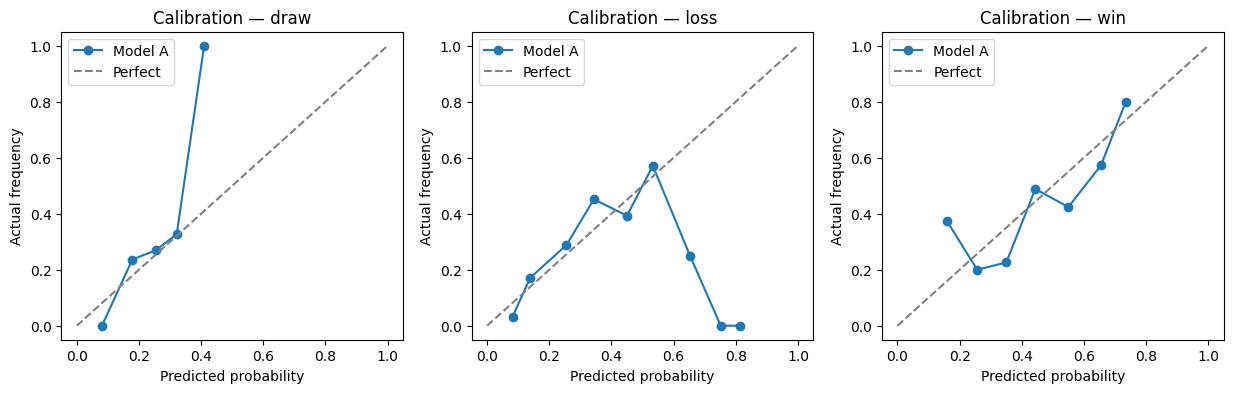

Test log loss: 1.0299


In [28]:
Test_Probs = model_a.predict_proba(X_test)  

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, outcome_label in enumerate(LE.classes_):
    y_true_binary = (y_test == i).astype(int)
    prob_true, prob_pred = calibration_curve(y_true_binary, Test_Probs[:, i], n_bins=10)
    
    axes[i].plot(prob_pred, prob_true, marker='o', label='Model A')
    axes[i].plot([0,1], [0,1], linestyle='--', color='grey', label='Perfect')
    axes[i].set_title(f'Calibration — {outcome_label}')
    axes[i].set_xlabel('Predicted probability')
    axes[i].set_ylabel('Actual frequency')
    axes[i].legend()

plt.show()

print(f"Test log loss: {log_loss(y_test, Test_Probs):.4f}")

# Poisson Match Simulation

In [29]:
def simulate_match(home_team, away_team, feature_row, model_b_home, model_b_away,
                   shootout_rates, knockout=False, n_sims=10_000):
    
    lambda_home = model_b_home.predict(feature_row)[0]
    lambda_away = model_b_away.predict(feature_row)[0]
    
    home_goals = np.random.poisson(lambda_home, n_sims)
    away_goals = np.random.poisson(lambda_away, n_sims)
    
    home_wins = (home_goals > away_goals).sum()
    away_wins = (away_goals > home_goals).sum()
    draws      = (home_goals == away_goals).sum()
    
    results = {
        'home_win_pct': home_wins / n_sims,
        'away_win_pct': away_wins / n_sims,
        'draw_pct':     draws / n_sims,
        'lambda_home':  lambda_home,
        'lambda_away':  lambda_away,
    }
    
    if knockout:
        et_lambda_home = lambda_home * 0.6 * (30/90)  
        et_lambda_away = lambda_away * 0.6 * (30/90)
        
        draw_indices = np.where(home_goals == away_goals)[0]
        
        et_home = np.random.poisson(et_lambda_home, len(draw_indices))
        et_away = np.random.poisson(et_lambda_away, len(draw_indices))
        
        et_home_wins = (et_home > et_away).sum()
        et_away_wins = (et_away > et_home).sum()
        et_still_draw = (et_home == et_away).sum()
        
        home_pen_rate = shootout_rates.set_index('team')['shootout_win_rate'].get(home_team, 0.5)
        away_pen_rate = shootout_rates.set_index('team')['shootout_win_rate'].get(away_team, 0.5)
        
        total = home_pen_rate + away_pen_rate
        home_pen_rate /= total
        
        pen_home_wins = np.random.binomial(et_still_draw, home_pen_rate)
        pen_away_wins = et_still_draw - pen_home_wins
        
        results['knockout_home_win_pct'] = (home_wins + et_home_wins + pen_home_wins) / n_sims
        results['knockout_away_win_pct'] = (away_wins + et_away_wins + pen_away_wins) / n_sims
    
    return results

# Monte Carlo Simulation and Result

In [30]:
elo_lookup_a = Schedule_Squad_Elo.dropna(subset=['a_elo']).set_index('team_a')['a_elo'].to_dict()
elo_lookup_b = Schedule_Squad_Elo.dropna(subset=['b_elo']).set_index('team_b')['b_elo'].to_dict()
elo_lookup   = {**elo_lookup_a, **elo_lookup_b}     

squad_cols = [
    'Squad',
    'Average Age',
    'WC Participations',
    'Foreigners',
    'Market Value(In Euros)',
    'Average Market Value(In Euros)'
]

squad_lookup_a = (
    Schedule_Squad_Elo.dropna(subset=['a_Market Value(In Euros)'])
    .drop_duplicates(subset=['team_a'])
    .set_index('team_a')[['a_' + c for c in squad_cols]]
    .rename(columns=lambda x: x.replace('a_', ''))
    .to_dict('index')
)

squad_lookup_b = (
    Schedule_Squad_Elo.dropna(subset=['b_Market Value(In Euros)'])
    .drop_duplicates(subset=['team_b'])
    .set_index('team_b')[['b_' + c for c in squad_cols]]
    .rename(columns=lambda x: x.replace('b_', ''))
    .to_dict('index')
)

squad_lookup = {**squad_lookup_a, **squad_lookup_b}

latest_form = (
   Team_Games[Team_Games['date'] <= '2026-06-10']
    .sort_values(['team', 'date'])
    .groupby('team').tail(5)
    .groupby('team')
    .agg(form_gf=('gf', 'mean'), form_ga=('ga', 'mean'), form_win_rate=('win', 'mean'))
    .reset_index()
)
form_lookup = latest_form.set_index('team').to_dict('index')

h2h_latest = (
    H2H.sort_values(['team', 'opponent', 'date'])
    .groupby(['team', 'opponent']).last()[['h2h_win_rate']]
    .reset_index()
)
h2h_dict = {(r['team'], r['opponent']): r['h2h_win_rate'] for _, r in h2h_latest.iterrows()}

In [31]:
league_avg_gf = Team_Games['gf'].mean()
league_avg_ga = Team_Games['ga'].mean()
league_avg_win = Team_Games['win'].mean()

print(f"League average GF: {league_avg_gf:.1f}, GA: {league_avg_ga:.1f}, Win Rate: {league_avg_win:.1f}")

League average GF: 1.3, GA: 1.3, Win Rate: 0.4


In [32]:
def build_feature_row(home_team, away_team):
    home_elo = elo_lookup.get(home_team, 1500)
    away_elo = elo_lookup.get(away_team, 1500)

    hf = form_lookup.get(home_team, {'form_gf': 1.3, 'form_ga': 1.3, 'form_win_rate': 0.4})
    af = form_lookup.get(away_team, {'form_gf': 1.3, 'form_ga': 1.3, 'form_win_rate': 0.4})

    h2h_wr = h2h_dict.get((home_team, away_team), 0.5)
    h2h_n  = 1 if (home_team, away_team) in h2h_dict else 0

    row = pd.DataFrame([{
        'home_elo':           home_elo,
        'away_elo':           away_elo,
        'elo_diff':           home_elo - away_elo,
        'home_form_gf':       hf['form_gf'],
        'home_form_ga':       hf['form_ga'],
        'home_form_win_rate': hf['form_win_rate'],
        'away_form_gf':       af['form_gf'],
        'away_form_ga':       af['form_ga'],
        'away_form_win_rate': af['form_win_rate'],
        'home_h2h_win_rate':  h2h_wr,
        'h2h_total_games':    h2h_n,
        'neutral':            1,
        'WC':                 1,
        'Qualifier':          0,
    }])
    return row[FEATURES]

In [33]:
group_matches = (
    Schedule_Squad_Elo[Schedule_Squad_Elo['status'] == 'confirmed_group_fixture']
    [['group', 'team_a', 'team_b']]
    .reset_index(drop=True)
)

groups = {}
for g in sorted(Schedule_Squad_Elo['group'].dropna().unique()):
    g_rows = Schedule_Squad_Elo[Schedule_Squad_Elo['group'] == g]
    teams  = list(dict.fromkeys(g_rows['team_a'].tolist() + g_rows['team_b'].tolist()))
    groups[g] = teams

print({g: len(t) for g, t in groups.items()}) 

{'A': 4, 'B': 4, 'C': 4, 'D': 4, 'E': 4, 'F': 4, 'G': 4, 'H': 4, 'I': 4, 'J': 4, 'K': 4, 'L': 4}


In [34]:
def simulate_single_match(home_team, away_team):
    row  = build_feature_row(home_team, away_team)
    lam_h = float(model_b_home.predict(row)[0])
    lam_a = float(model_b_away.predict(row)[0])
    return np.random.poisson(lam_h), np.random.poisson(lam_a)


def compute_standings(group_teams, scorelines):
    stats = {t: {'pts': 0, 'gf': 0, 'ga': 0, 'gd': 0} for t in group_teams}

    for (home, away), (home_goals, away_goals) in scorelines.items():
        stats[home]['gf'] += home_goals;  stats[home]['ga'] += away_goals
        stats[away]['gf'] += away_goals;  stats[away]['ga'] += home_goals
        stats[home]['gd'] = stats[home]['gf'] - stats[home]['ga']
        stats[away]['gd'] = stats[away]['gf'] - stats[away]['ga']

        if home_goals > away_goals:   stats[home]['pts'] += 3
        elif home_goals == away_goals: stats[home]['pts'] += 1; stats[away]['pts'] += 1
        else:          stats[away]['pts'] += 3

    table = (pd.DataFrame(stats).T
               .reset_index().rename(columns={'index': 'team'})
               .sort_values(['pts', 'gd', 'gf'], ascending=False)
               .reset_index(drop=True))
    table['position'] = range(1, 5)
    return table

In [35]:
THIRD_PLACE_SLOT_MAP = {
    74:  'Group A/B/C/D/F 3rd Place',
    77:  'Group C/D/F/G/H 3rd Place',
    79:  'Group C/E/F/H/I 3rd Place',
    80:  'Group E/H/I/J/K 3rd Place',  
    81:  'Group B/E/F/I/J 3rd Place',  
    82:  'Group A/E/H/I/J 3rd Place', 
    85:  'Group E/F/G/I/J 3rd Place',  
    87:  'Group D/E/I/J/L 3rd Place',  
}

def select_best_third(third_place_teams):
    df = pd.DataFrame(third_place_teams)
    df = df.sort_values(['pts', 'gd', 'gf'], ascending=False).reset_index(drop=True)
    return df.head(8)['team'].tolist()

In [36]:
r32_bracket = (
    Schedule_Squad_Elo[
        (Schedule_Squad_Elo['stage'] == 'Round of 32') &
        (Schedule_Squad_Elo['status'] == 'bracket_slot')
    ][['match_number', 'team_a', 'team_b']]
    .reset_index(drop=True)
)

def resolve_slot(slot_str, group_winners, group_runners, best_third):
    if 'Winner' in slot_str and '3rd' not in slot_str:
        group = slot_str.split('Group ')[-1].split(' ')[0]
        return group_winners[group]
    elif 'Runner-up' in slot_str:
        group = slot_str.split('Group ')[-1].split(' ')[0]
        return group_runners[group]
    elif '3rd Place' in slot_str:
        return best_third.pop(0)
    return None


def run_tournament():
    group_winners   = {}
    group_runners   = {}
    third_place_all = []
    group_scorelines = {}

    for group_letter, teams in groups.items():
        scorelines = {}
        for home, away in combinations(teams, 2):
            scorelines[(home, away)] = simulate_single_match(home, away)

        table = compute_standings(teams, scorelines)
        group_winners[group_letter]  = table.iloc[0]['team']
        group_runners[group_letter]  = table.iloc[1]['team']
        third_place_all.append({
            'team':  table.iloc[2]['team'],
            'pts':   table.iloc[2]['pts'],
            'gd':    table.iloc[2]['gd'],
            'gf':    table.iloc[2]['gf'],
            'group': group_letter
        })
        group_scorelines[group_letter] = scorelines

    best_third = select_best_third(third_place_all)

    r32_pairs = []
    for _, row in r32_bracket.iterrows():
        home = resolve_slot(row['team_a'], group_winners, group_runners, best_third)
        away = resolve_slot(row['team_b'], group_winners, group_runners, best_third)
        r32_pairs.append((home, away))

    def simulate_knockout_match(home, away):
        row   = build_feature_row(home, away)
        lam_h = float(model_b_home.predict(row)[0])
        lam_a = float(model_b_away.predict(row)[0])
        hg    = np.random.poisson(lam_h)
        ag    = np.random.poisson(lam_a)

        if hg != ag:
            return (home if hg > ag else away), hg, ag, '90'

        et_lam_h = lam_h * 0.6 * (30/90)
        et_lam_a = lam_a * 0.6 * (30/90)
        et_hg = np.random.poisson(et_lam_h)
        et_ag = np.random.poisson(et_lam_a)

        if et_hg != et_ag:
            return (home if et_hg > et_ag else away), hg + et_hg, ag + et_ag, 'AET'

        h_pen = Shootout_Rates.set_index('team')['shootout_win_rate'].get(home, 0.5)
        a_pen = Shootout_Rates.set_index('team')['shootout_win_rate'].get(away, 0.5)
        winner = home if np.random.random() < h_pen / (h_pen + a_pen) else away
        return winner, hg, ag, 'PEN'

    def play_round(pairs):
        results  = []
        winners  = []
        for home, away in pairs:
            winner, hg, ag, how = simulate_knockout_match(home, away)
            winners.append(winner)
            results.append({
                'home': home, 'away': away,
                'home_goals': hg, 'away_goals': ag,
                'winner': winner, 'decided_by': how
            })
        return winners, results

    r32_winners,  r32_results  = play_round(r32_pairs)
    r16_pairs                  = list(zip(r32_winners[0::2], r32_winners[1::2]))
    r16_winners,  r16_results  = play_round(r16_pairs)
    qf_pairs                   = list(zip(r16_winners[0::2], r16_winners[1::2]))
    qf_winners,   qf_results   = play_round(qf_pairs)
    sf_pairs                   = list(zip(qf_winners[0::2], qf_winners[1::2]))
    sf_winners,   sf_results   = play_round(sf_pairs)
    champion, hg, ag, how      = simulate_knockout_match(sf_winners[0], sf_winners[1])

    return {
        'champion':         champion,
        'finalist_a':       sf_winners[0],
        'finalist_b':       sf_winners[1],
        'semis':            qf_winners,
        'quarters':         r16_winners,
        'r32':              r32_winners,
        'group_winners':    group_winners,
        'group_runners':    group_runners,
        'group_scorelines': group_scorelines,
        'r32_results':      r32_results,
        'r16_results':      r16_results,
        'qf_results':       qf_results,
        'sf_results':       sf_results,
        'final':            {'home': sf_winners[0], 'away': sf_winners[1],
                             'home_goals': hg, 'away_goals': ag,
                             'winner': champion, 'decided_by': how}
    }

In [37]:
np.random.seed(42)

N_SIMS  = 10_000
records = []

for i in range(N_SIMS):
    if i % 1000 == 0:
        print(f"Simulation {i}/{N_SIMS}...")
    records.append(run_tournament())

champions = Counter(r['champion']   for r in records)
finalists = Counter(r['finalist_a'] for r in records) + Counter(r['finalist_b'] for r in records)
semifinal = Counter(t for r in records for t in r['semis'])
quarter   = Counter(t for r in records for t in r['quarters'])

results_table = pd.DataFrame({'team': list(elo_lookup.keys())})
results_table['win_%'] = results_table['team'].map(champions)  / N_SIMS * 100
results_table['final_%'] = results_table['team'].map(finalists)  / N_SIMS * 100
results_table['semi_%'] = results_table['team'].map(semifinal)  / N_SIMS * 100
results_table['qf_%'] = results_table['team'].map(quarter)    / N_SIMS * 100
results_table = results_table.fillna(0).sort_values('win_%', ascending=False).reset_index(drop=True)

results_table.style.format({
    'win_%':   '{:.1f}%',
    'final_%': '{:.1f}%',
    'semi_%':  '{:.1f}%',
    'qf_%':    '{:.1f}%',
}).background_gradient(subset=['win_%'], cmap='Greens')

Simulation 0/10000...
Simulation 1000/10000...


C:\Users\User\AppData\Local\Temp\ipykernel_16972\424096215.py:72: RuntimeWarning: invalid value encountered in scalar divide
  winner = home if np.random.random() < h_pen / (h_pen + a_pen) else away
C:\Users\User\AppData\Local\Temp\ipykernel_16972\424096215.py:72: RuntimeWarning: invalid value encountered in scalar divide
  winner = home if np.random.random() < h_pen / (h_pen + a_pen) else away


Simulation 2000/10000...


C:\Users\User\AppData\Local\Temp\ipykernel_16972\424096215.py:72: RuntimeWarning: invalid value encountered in scalar divide
  winner = home if np.random.random() < h_pen / (h_pen + a_pen) else away
C:\Users\User\AppData\Local\Temp\ipykernel_16972\424096215.py:72: RuntimeWarning: invalid value encountered in scalar divide
  winner = home if np.random.random() < h_pen / (h_pen + a_pen) else away


Simulation 3000/10000...


...

C:\Users\User\AppData\Local\Temp\ipykernel_16972\424096215.py:72: RuntimeWarning: invalid value encountered in scalar divide
  winner = home if np.random.random() < h_pen / (h_pen + a_pen) else away


Simulation 5000/10000...


C:\Users\User\AppData\Local\Temp\ipykernel_16972\424096215.py:72: RuntimeWarning: invalid value encountered in scalar divide
  winner = home if np.random.random() < h_pen / (h_pen + a_pen) else away


Simulation 6000/10000...
Simulation 7000/10000...
Simulation 8000/10000...
Simulation 9000/10000...


,team,win_%,final_%,semi_%,qf_%
0,France,8.4%,13.8%,25.2%,37.7%
1,Argentina,7.2%,13.5%,23.3%,36.0%
2,Spain,7.2%,14.2%,22.0%,34.4%
3,Germany,6.3%,10.2%,18.7%,29.1%
4,Brazil,6.2%,10.3%,16.0%,30.6%
5,Portugal,5.5%,10.7%,19.6%,36.2%
6,Ecuador,5.0%,8.8%,16.9%,28.5%
7,Colombia,4.1%,8.2%,15.7%,31.3%
8,Belgium,3.7%,7.7%,14.2%,26.8%
9,Netherlands,3.6%,6.5%,12.2%,26.4%
